## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU

2026-04-10 11:48:19.724670: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775821699.908827      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775821699.961340      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775821700.396827      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775821700.396883      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775821700.396887      55 computation_placer.cc:177] computation placer alr

## Load Dataset

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/tweets/Tweets.csv') 
df = df[['text', 'sentiment']].dropna()

## Encode Labels

In [4]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

### Sentiment Distribution graph

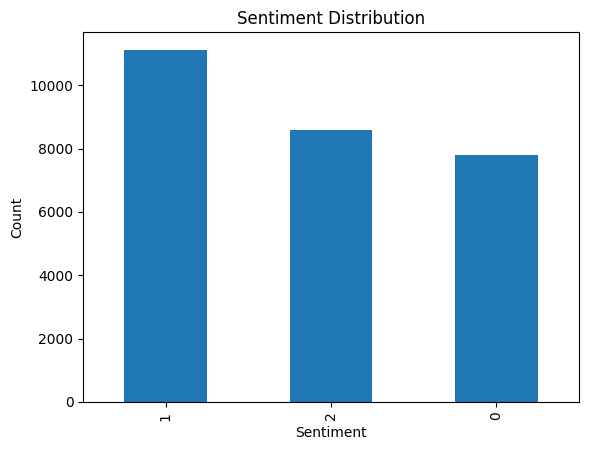

In [5]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## Tokenize Text

In [6]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X, maxlen=50)

y = df['sentiment']

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build Models

### RNN Model

In [8]:
rnn_model = Sequential([
    Embedding(5000, 64, input_length=50),
    SimpleRNN(64),
    Dense(3, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_rnn= rnn_model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-04-10 11:51:31.343427: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4518 - loss: 1.0285
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7380 - loss: 0.6389
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8585 - loss: 0.3955
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9327 - loss: 0.2145
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9558 - loss: 0.1365


### LSTM Model

In [9]:
lstm_model = Sequential([
    Embedding(5000, 64, input_length=50),
    LSTM(64),
    Dense(3, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_lstm = lstm_model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.5391 - loss: 0.9299
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7565 - loss: 0.6049
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7945 - loss: 0.5248
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8157 - loss: 0.4756
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8432 - loss: 0.4172


### GRU Model

In [10]:
gru_model = Sequential([
    Embedding(5000, 64, input_length=50),
    GRU(64),
    Dense(3, activation='softmax')
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_gru = gru_model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.5483 - loss: 0.9202
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7588 - loss: 0.6003
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7950 - loss: 0.5125
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8338 - loss: 0.4332
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8600 - loss: 0.3760


## Evaluation

In [11]:
rnn_acc = rnn_model.evaluate(X_test, y_test)[1]
lstm_acc = lstm_model.evaluate(X_test, y_test)[1]
gru_acc = gru_model.evaluate(X_test, y_test)[1]

print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy:", gru_acc)

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6219 - loss: 1.3605
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7130 - loss: 0.7254
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7018 - loss: 0.8007
RNN Accuracy: 0.6246361136436462
LSTM Accuracy: 0.7097889184951782
GRU Accuracy: 0.7026928663253784


## Accuracy Comparison

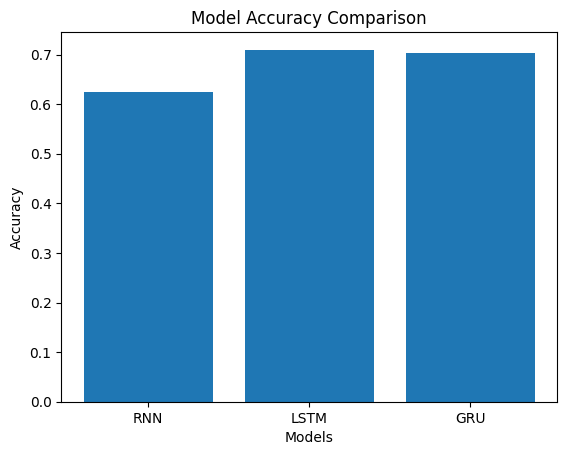

In [12]:
models = ['RNN', 'LSTM', 'GRU']
accuracies = [rnn_acc, lstm_acc, gru_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

## Loss Curve

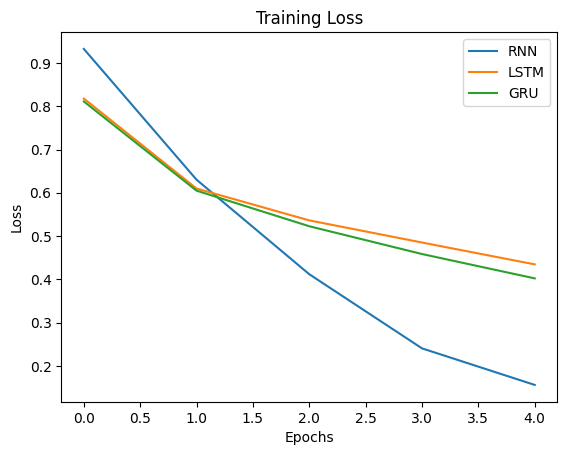

In [13]:
plt.figure()
plt.plot(history_rnn.history['loss'], label='RNN')
plt.plot(history_lstm.history['loss'], label='LSTM')
plt.plot(history_gru.history['loss'], label='GRU')

plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Accuracy Curve

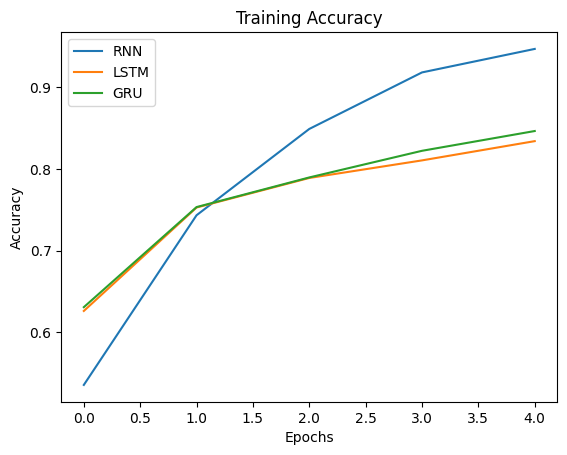

In [14]:
plt.figure()
plt.plot(history_rnn.history['accuracy'], label='RNN')
plt.plot(history_lstm.history['accuracy'], label='LSTM')
plt.plot(history_gru.history['accuracy'], label='GRU')

plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Confusion Matrix

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


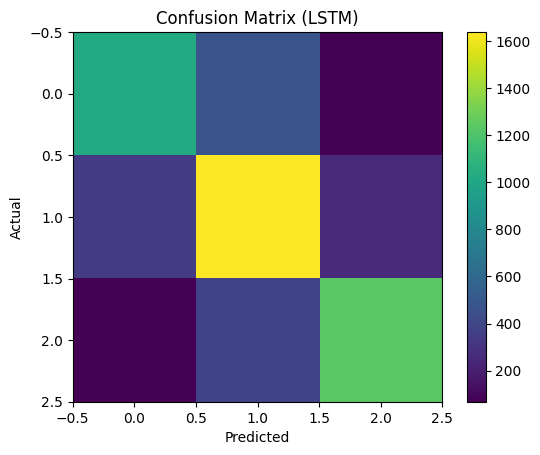

In [16]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = np.argmax(lstm_model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (LSTM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()